In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples



In [3]:
# Loading scaled features
df = pd.read_csv("../../data/claims_train_scaled.csv")
df.drop(columns=["Area","VehBrand","VehGas","Region","ClaimNb"],inplace=True)


In [4]:
import matplotlib.pyplot as plt
# Trying on 1-20 clusters
inertiaList = []
K = range(1, 20)
for j in K:
    clusters = KMeans(n_clusters=j).fit(df)
    print(f"for n clusters = ", j, " The inertia is: ", clusters.inertia_)
    inertiaList.append(clusters.inertia_)



for n clusters =  1  The inertia is:  2776701.5324542206
for n clusters =  2  The inertia is:  2204154.6303283307
for n clusters =  3  The inertia is:  1894741.4129819481
for n clusters =  4  The inertia is:  1642883.115623699
for n clusters =  5  The inertia is:  1296003.463298876
for n clusters =  6  The inertia is:  1145657.1876114425
for n clusters =  7  The inertia is:  1078078.4896765673
for n clusters =  8  The inertia is:  1043508.3721743502
for n clusters =  9  The inertia is:  981646.0702505754
for n clusters =  10  The inertia is:  968628.1252895894
for n clusters =  11  The inertia is:  896973.6304466655
for n clusters =  12  The inertia is:  883390.2121450836
for n clusters =  13  The inertia is:  823465.4442888239
for n clusters =  14  The inertia is:  803272.8940807616
for n clusters =  15  The inertia is:  787444.6286595966
for n clusters =  16  The inertia is:  756705.9020170792
for n clusters =  17  The inertia is:  747440.453511244
for n clusters =  18  The inertia i

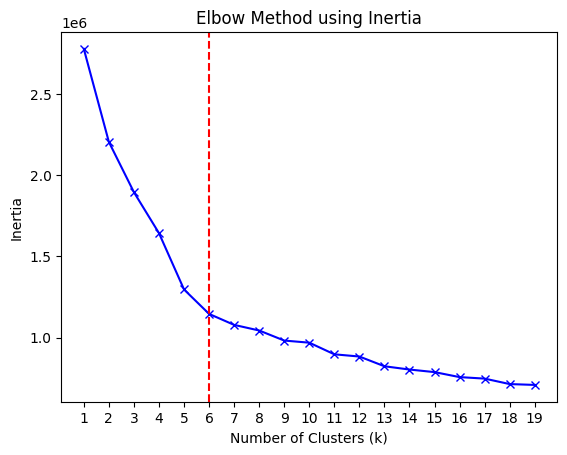

In [5]:
plt.plot(K, inertiaList, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.axvline(x=6, color="red", linestyle='--')
plt.title('Elbow Method using Inertia')
plt.show()

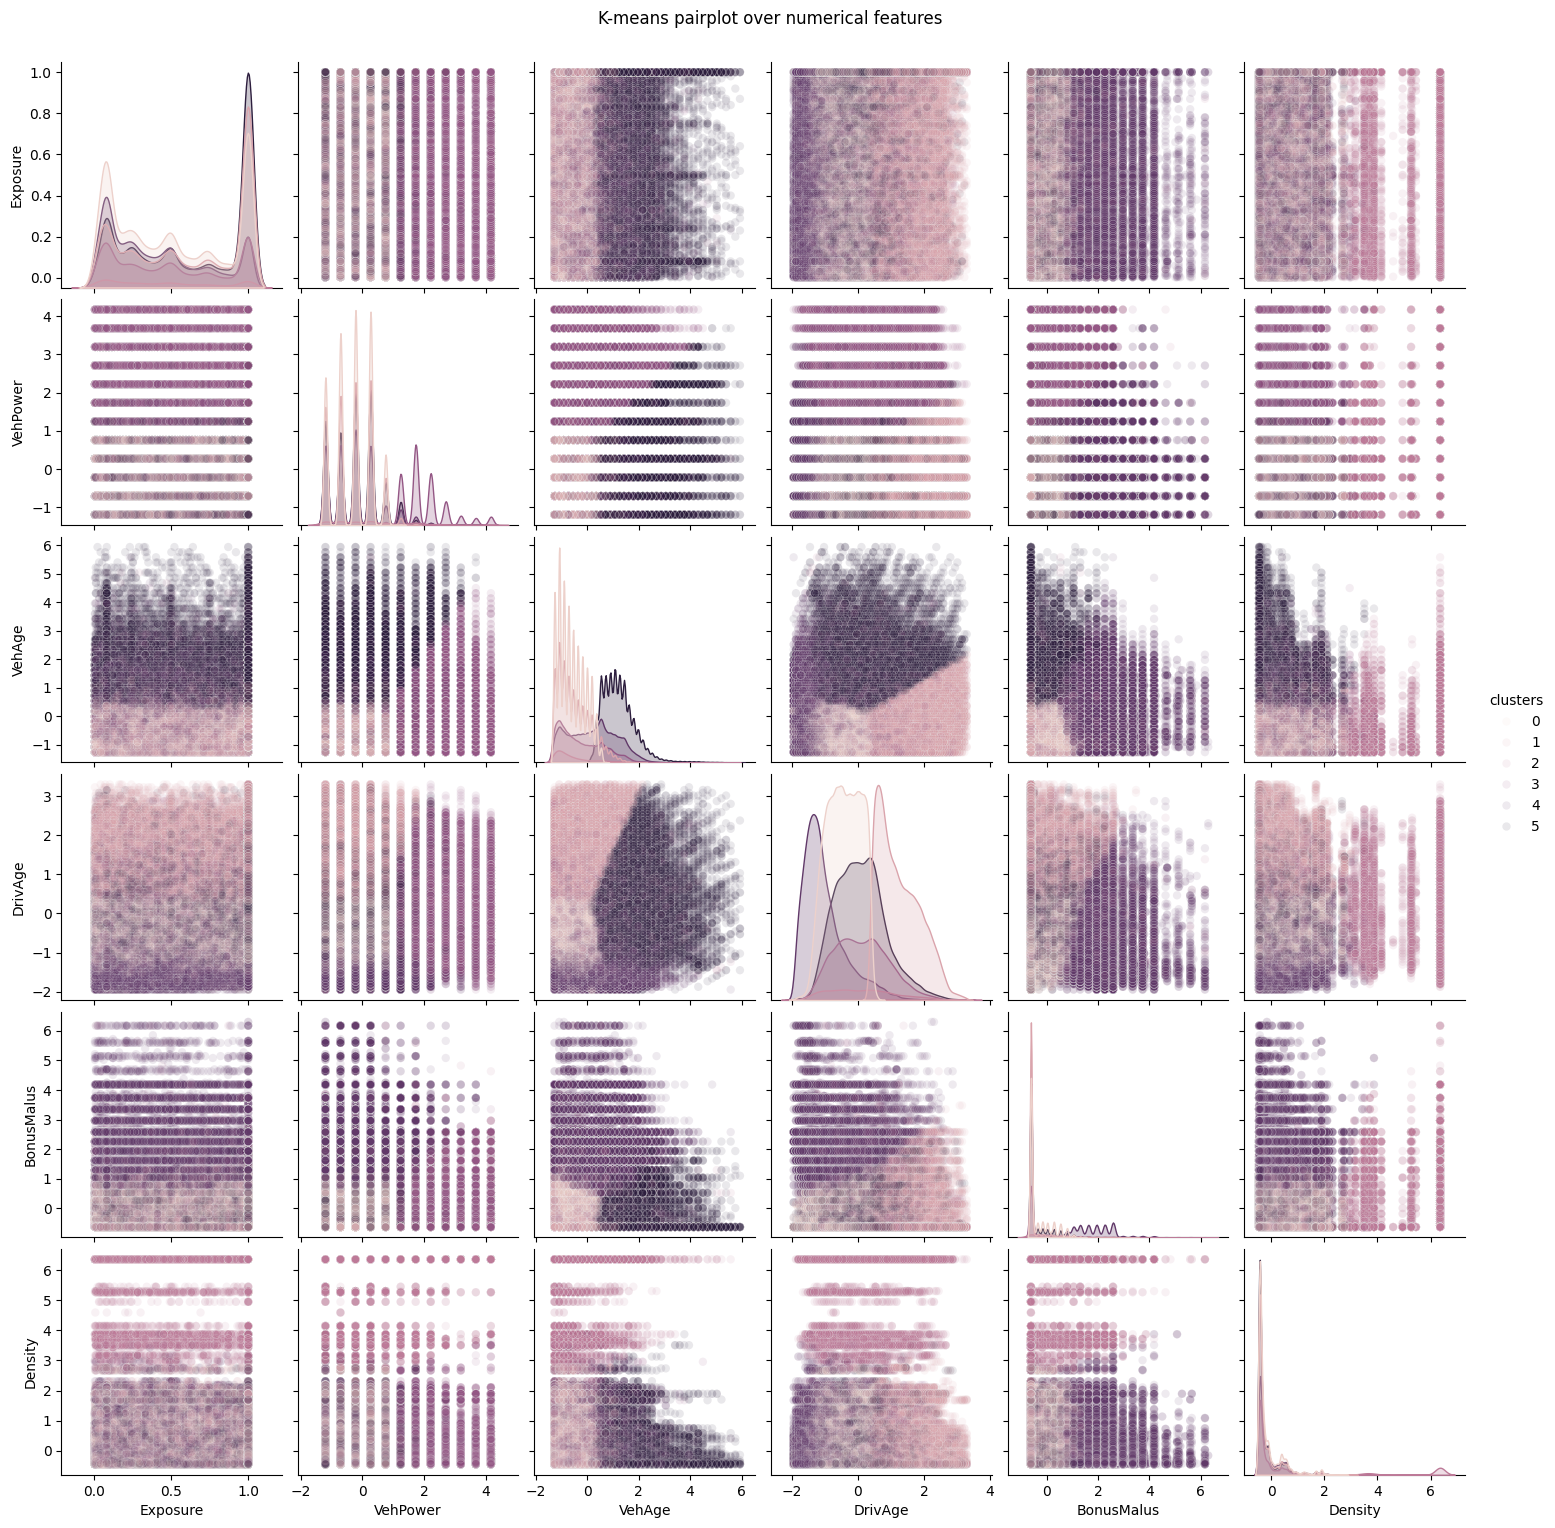

In [6]:
# Using n_clusters = 6
df['clusters'] = KMeans(n_clusters=6).fit_predict(df)
pairPlot = sns.pairplot(df, hue='clusters', plot_kws={'alpha': 0.1})
pairPlot.figure.suptitle("K-means pairplot over numerical features", y=1.02)
df.drop(columns=['clusters'], inplace=True)
